# Fraud Detection – Model Evaluation

Objective:
- Evaluate XGBoost performance
- Analyze confusion matrix
- Plot ROC curve
- Examine feature importance

In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier

In [2]:
X_train = joblib.load("../data/X_train_processed.pkl")
X_test = joblib.load("../data/X_test_processed.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

In [3]:
fraud = np.sum(y_train == 1)
non_fraud = np.sum(y_train == 0)

scale_pos_weight = non_fraud / fraud

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

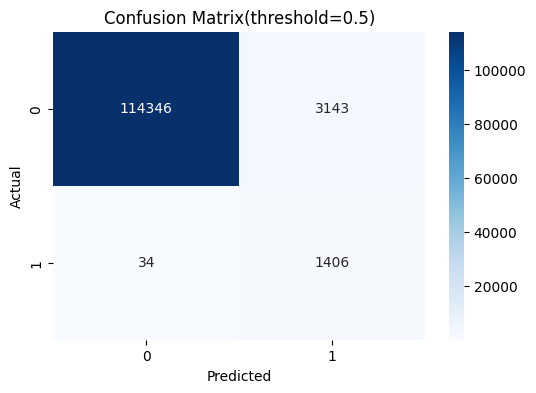

In [4]:
y_pred = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix(threshold=0.5)')
plt.show()

### Confusion Matrix Insight

- True Positives: Correctly detected fraud
- False Positives: Normal transactions flagged as fraud
- False Negatives: Missed fraud transactions
- Model prioritizes high recall (low false negatives)

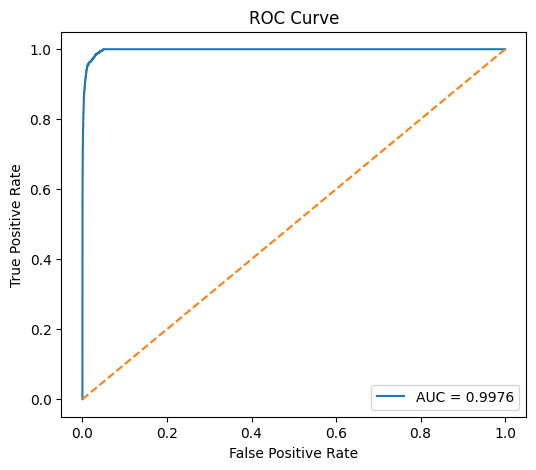

AUC Score: 0.9976462187713082


In [5]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

### ROC Insight

- AUC measures model’s ability to distinguish fraud vs non-fraud.
- Higher AUC indicates better ranking capability.
- XGBoost should show strong AUC due to gradient boosting.

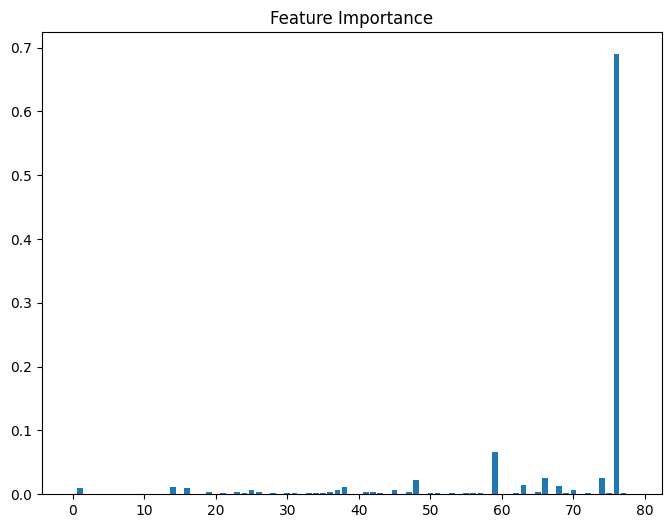

In [6]:
importances = xgb_model.feature_importances_

plt.figure(figsize=(8,6))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

In [7]:
joblib.dump(importances, "../models/feature_importance.pkl")

['../models/feature_importance.pkl']

### Feature Importance Insight

- Transaction amount is expected to be highly important.
- Certain categories and merchants contribute strongly.
- Model learns complex feature interactions.